In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.ImageOps import expand
from numpy import dtype

In [2]:
df=pd.read_csv('titanic_large.csv')

In [3]:
print(df.shape)


(100000, 11)


In [4]:
print(df.head())


   PassengerId  Survived  Pclass                      Name     Sex   Age  \
0        75722         0       3  Robinson, Master. Steven    male  55.6   
1        80185         1       2   Wilson, Master. Richard    male  85.0   
2        19865         1       2         Taylor, Ms. Betty  female   NaN   
3        76700         1       3     Smith, Mrs. Elizabeth  female  13.3   
4        92992         0       1      Jackson, Rev. Daniel    male  55.9   

   SibSp  Parch  Ticket   Fare Embarked  
0      2      3  600542   3.02        Q  
1      1      0  561216   8.68        S  
2      0      0  589751   4.61        S  
3      0      0   96366   5.56        S  
4      0      1  416388  40.64        S  


In [5]:
print(df['Pclass'].value_counts())
print(df['Embarked'].value_counts())
print(df['SibSp'].value_counts())

Pclass
3    54907
2    25132
1    19961
Name: count, dtype: int64
Embarked
S    80128
C     9985
Q     9887
Name: count, dtype: int64
SibSp
0    54858
1    32920
2     9882
3     1992
4      305
5       38
6        5
Name: count, dtype: int64


In [6]:
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket           int64
Fare           float64
Embarked           str
dtype: object

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,100000.000000,100000.000000,100000.000000,80144.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,0.396190,2.349460,31.731833,0.601000,0.398230,505207.036760,16.437273
std,28867.657797,0.489107,0.791558,18.985651,0.776315,0.631036,285402.595345,23.823469
min,1.000000,0.000000,1.000000,0.400000,0.000000,0.000000,10009.000000,0.000000
25%,25000.750000,0.000000,2.000000,16.100000,0.000000,0.000000,258419.250000,3.970000
50%,50000.500000,0.000000,3.000000,30.800000,0.000000,0.000000,505116.500000,7.500000
75%,75000.250000,1.000000,3.000000,44.225000,1.000000,1.000000,751605.500000,17.950000
max,100000.000000,1.000000,3.000000,85.000000,6.000000,6.000000,999999.000000,348.910000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PassengerId  100000 non-null  int64  
 1   Survived     100000 non-null  int64  
 2   Pclass       100000 non-null  int64  
 3   Name         100000 non-null  str    
 4   Sex          100000 non-null  str    
 5   Age          80144 non-null   float64
 6   SibSp        100000 non-null  int64  
 7   Parch        100000 non-null  int64  
 8   Ticket       100000 non-null  int64  
 9   Fare         100000 non-null  float64
 10  Embarked     100000 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 8.4 MB


In [9]:
df.isnull().sum()


PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age            19856
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
dtype: int64

In [10]:
print(df['Age'].value_counts())


Age
0.4     1223
85.0     516
9.7      194
35.5     190
37.1     189
        ... 
83.2       5
84.0       5
84.2       4
84.5       4
84.8       4
Name: count, Length: 847, dtype: int64


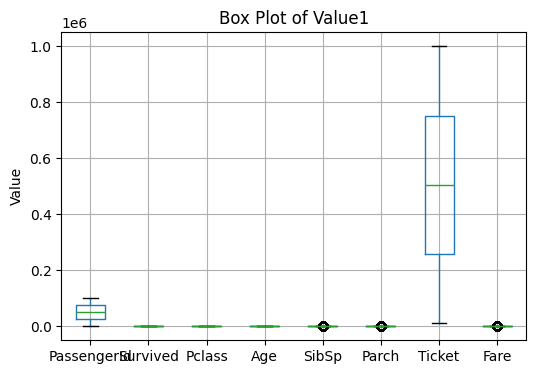

In [11]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.figure(figsize=(6, 4))
df.boxplot()
plt.title('Box Plot of Value1')
plt.ylabel('Value')
plt.show()

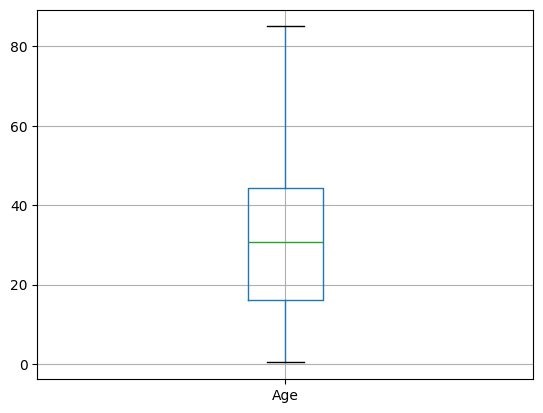

<Figure size 600x400 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
plt.style.use('default')
df.boxplot(column=["Age"])
plt.figure(figsize=(6, 4))
plt.show()

In [13]:
null_counts_per_row = df.isna().sum(axis=0)
null_counts_per_row

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age            19856
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
dtype: int64

In [14]:
print(df[df['Age'].isnull()]['Pclass'].value_counts())
print(df[df['Age'].isnull()]['SibSp'].value_counts())
print(df[df['Age'].isnull()]['Parch'].value_counts())


Pclass
3    10973
2     4961
1     3922
Name: count, dtype: int64
SibSp
0    10819
1     6575
2     1999
3      388
4       70
5        5
Name: count, dtype: int64
Parch
0    13331
1     5318
2     1053
3      133
4       20
5        1
Name: count, dtype: int64


In [15]:
df_grouped=df.groupby('Pclass').agg({'Age':['median','mean'],'Fare':['mean']})
print(df_grouped)

          Age                  Fare
       median       mean       mean
Pclass                             
1        30.9  31.845751  49.451641
2        31.0  31.908160  13.965097
3        30.7  31.609289   5.566726


In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [17]:
df.loc[(df['Pclass']==3) & (df['Age'].isnull()),['Age']]=30

In [18]:
df.loc[(df['Pclass']==2) & (df['Age'].isnull()),['Age']]=30

In [19]:
df.loc[(df['Pclass']==1) & (df['Age'].isnull()),['Age']]=30

In [20]:
print(df['Age'].isnull().sum())


0


In [21]:
df[['lastname','title_first']]=df['Name'].str.strip().str.lower().str.split(',', expand=True)

In [22]:
df['firstname']=df['title_first'].str.extract(r'\w*\.\s*(.*)')
df=df.drop(columns=['title_first'])

In [23]:
df['full']=df['firstname'].str.cat(df['lastname'],sep=' ')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,lastname,firstname,full
0,75722,0,3,"Robinson, Master. Steven",male,55.6,2,3,600542,3.02,Q,robinson,steven,steven robinson
1,80185,1,2,"Wilson, Master. Richard",male,85.0,1,0,561216,8.68,S,wilson,richard,richard wilson
2,19865,1,2,"Taylor, Ms. Betty",female,30.0,0,0,589751,4.61,S,taylor,betty,betty taylor
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13.3,0,0,96366,5.56,S,smith,elizabeth,elizabeth smith
4,92992,0,1,"Jackson, Rev. Daniel",male,55.9,0,1,416388,40.64,S,jackson,daniel,daniel jackson
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,0,3,"Robinson, Rev. James",male,32.0,1,1,219100,2.53,S,robinson,james,james robinson
99996,54887,0,3,"Jackson, Mr. Donald",male,25.5,0,0,403270,17.17,S,jackson,donald,donald jackson
99997,76821,0,2,"Wilson, Rev. Donald",male,30.0,1,0,345632,12.25,S,wilson,donald,donald wilson
99998,861,0,3,"Robinson, Mr. Donald",male,32.8,0,1,798295,6.16,C,robinson,donald,donald robinson


In [26]:
df['familysize']=df['SibSp']+df['Parch']+1
df['status']='lonely'
df.loc[df['familysize']>1 ,'status']='with family'
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,lastname,firstname,full,familysize,status,age_group
0,75722,0,3,"Robinson, Master. Steven",male,55.6,2,3,600542,3.02,Q,robinson,steven,steven robinson,6,with family,adult
1,80185,1,2,"Wilson, Master. Richard",male,85.0,1,0,561216,8.68,S,wilson,richard,richard wilson,2,with family,old
2,19865,1,2,"Taylor, Ms. Betty",female,30.0,0,0,589751,4.61,S,taylor,betty,betty taylor,1,lonely,teen
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13.3,0,0,96366,5.56,S,smith,elizabeth,elizabeth smith,1,lonely,child
4,92992,0,1,"Jackson, Rev. Daniel",male,55.9,0,1,416388,40.64,S,jackson,daniel,daniel jackson,2,with family,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,0,3,"Robinson, Rev. James",male,32.0,1,1,219100,2.53,S,robinson,james,james robinson,3,with family,teen
99996,54887,0,3,"Jackson, Mr. Donald",male,25.5,0,0,403270,17.17,S,jackson,donald,donald jackson,1,lonely,teen
99997,76821,0,2,"Wilson, Rev. Donald",male,30.0,1,0,345632,12.25,S,wilson,donald,donald wilson,2,with family,teen
99998,861,0,3,"Robinson, Mr. Donald",male,32.8,0,1,798295,6.16,C,robinson,donald,donald robinson,2,with family,teen


In [29]:
df_drop=df.drop(columns=['Name'])

In [30]:
df["new_fare"]=df_drop.groupby("Pclass")["Fare"].transform('mean')
print(df["new_fare"])

0         5.566726
1        13.965097
2        13.965097
3         5.566726
4        49.451641
           ...    
99995     5.566726
99996     5.566726
99997    13.965097
99998     5.566726
99999    49.451641
Name: new_fare, Length: 100000, dtype: float64


In [37]:
df["new_cum"]=df.groupby("Pclass")["Fare"].transform('sum')
print(df[['new_cum','Fare','Pclass']])

         new_cum   Fare  Pclass
0      305652.24   3.02       3
1      350970.81   8.68       2
2      350970.81   4.61       2
3      305652.24   5.56       3
4      987104.21  40.64       1
...          ...    ...     ...
99995  305652.24   2.53       3
99996  305652.24  17.17       3
99997  350970.81  12.25       2
99998  305652.24   6.16       3
99999  987104.21  14.02       1

[100000 rows x 3 columns]


In [47]:
df["rank"]=df["Fare"].rank(method='dense',ascending=False)
df.sort_values(by=['Fare'],ascending=False,inplace=True)
print(df[["rank","Fare"]])

         rank    Fare
56545     1.0  348.91
17555     2.0  332.77
45302     3.0  313.31
45237     4.0  311.99
66479     5.0  310.48
...       ...     ...
78126  9515.0    0.00
52797  9515.0    0.00
76014  9515.0    0.00
95671  9515.0    0.00
52758  9515.0    0.00

[100000 rows x 2 columns]


In [54]:
df.sort_index(ascending=True,inplace=True)
df["moving_avg"]=df['Fare'].rolling(window=3).mean()

print(df[["moving_avg","Fare"]])

       moving_avg   Fare
0             NaN   3.02
1             NaN   8.68
2        5.436667   4.61
3        6.283333   5.56
4       16.936667  40.64
...           ...    ...
99995   64.603333   2.53
99996   15.073333  17.17
99997   10.650000  12.25
99998   11.860000   6.16
99999   10.810000  14.02

[100000 rows x 2 columns]


In [56]:
df["pre_fare"]=df["Fare"].shift(1)
print(df[["pre_fare","Fare"]])

       pre_fare   Fare
0           NaN   3.02
1          3.02   8.68
2          8.68   4.61
3          4.61   5.56
4          5.56  40.64
...         ...    ...
99995     25.52   2.53
99996      2.53  17.17
99997     17.17  12.25
99998     12.25   6.16
99999      6.16  14.02

[100000 rows x 2 columns]


In [62]:
df["fare_cum"]=df.groupby(df["Pclass"])["Fare"].cumsum()
df.sort_values(by=["Pclass"],ascending=False)
print(df[["fare_cum","Fare","Pclass"]])

        fare_cum   Fare  Pclass
0           3.02   3.02       3
1           8.68   8.68       2
2          13.29   4.61       2
3           8.58   5.56       3
4          40.64  40.64       1
...          ...    ...     ...
99995  305628.91   2.53       3
99996  305646.08  17.17       3
99997  350970.81  12.25       2
99998  305652.24   6.16       3
99999  987104.21  14.02       1

[100000 rows x 3 columns]
